<a href="https://colab.research.google.com/github/R23062/idk/blob/main/eii2_%E7%AC%AC04%E5%9B%9E_2026_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **実装課題1について**

- 詳細は [こちら](https://colab.research.google.com/drive/19fD8m6jiqRHGNJq86EjJV0lytpAYcyj2?usp=sharing) を参照してください（期限は **<font color="deeppink">8月末</font>** に設定しています）。
  - 前回案内した「[報告書1](https://colab.research.google.com/drive/147iZ0SBQ5iMW0GGkIHpc6FtIi2zwMoKB?usp=sharing)」とは別の **提出物** です。


# **準備**

- 今回は、データ可視化および統計処理の「**第4週目**」です。次回からの2週は「ウェブアプリのセキュリティ」がテーマになります。
  - 資料 👉 https://takeshiwada1980.github.io/Eii2-2025/（昨年度参考）
  

In [ ]:
# matplotlib で日本語を使用するためのパッケージのインストール
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 17.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=267f54e2009c0352cb8cc0cb0ee3648763ea8aedfd2edf76c24d77c9ea3aeec0
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


# **演習用データの準備**

次のコードセルで生成するCSVファイル `measurement.csv` は、以下のような架空のシナリオ・設定に基づいています。

> ある食品会社の工場では、豚饅（ぶたまん）の生産を行っている。製造工程の中核を担っているのは、バルク生地（未分割の皮生地）と餡具材を投入し、一定重量に分割・充填・成形して豚饅を製造する「**自動充填成形機**」であり、この機械が全 $8$ ラインで並行稼働している。
>
> ここで重要となるのが、豚饅の重量（標準 $100\,g$）である。品質管理担当者は、$1$ 時間ごとに $8$ 台の自動充填成形機から無作為に豚饅をサンプリングし、それぞれの重量（$g$）を測定する作業を、計 $100$ 回にわたって実施した。


In [ ]:
#@title ■ 演習用のCSVデータ measurement.csv の生成 { display-mode: "form" }
%%writefile measurement.csv
machine1,machine2,machine3,machine4,machine5,machine6,machine7,machine8
76,120,126,97,79,98,97,100
76,112,106,103,110,98,103,100
78,93,110,93,77,136,93,100
81,92,121,82,106,92,109,99
82,112,86,86,96,140,106,98
84,110,96,87,94,100,105,98
84,102,90,88,110,98,114,97
85,103,99,81,81,98,82,97
85,96,97,94,100,134,86,96
86,107,89,95,101,106,87,95
86,100,85,84,106,98,115,95
87,123,96,87,92,102,113,95
89,113,84,89,102,95,113,94
89,109,104,99,110,103,88,93
90,103,116,101,110,92,81,92
90,117,109,94,110,98,94,91
90,95,99,93,110,98,106,91
91,113,111,87,110,94,118,90
91,90,116,83,107,96,109,89
91,97,102,97,96,100,104,87
92,89,96,83,95,105,95,86
92,101,101,99,101,106,84,85
92,93,94,91,110,98,87,84
93,107,102,87,101,98,107,81
93,97,107,91,105,94,103,76
94,107,98,99,93,98,108,76
94,95,105,90,110,96,89,78
95,89,85,89,95,96,99,82
95,96,100,90,110,98,101,84
95,95,103,81,98,93,104,85
95,106,101,100,110,100,116,86
95,100,105,91,90,108,94,89
96,104,113,92,108,100,93,90
96,106,105,88,93,111,87,90
97,106,99,86,110,92,117,91
97,104,98,96,110,87,106,92
97,91,99,94,86,94,107,92
97,85,96,91,109,102,83,93
97,108,90,90,84,96,97,94
98,95,97,91,100,92,83,95
98,101,90,88,73,108,104,95
98,82,95,92,100,104,105,96
98,109,91,95,89,111,106,97
99,84,110,94,96,98,99,97
100,76,106,94,110,104,91,97
100,108,94,95,93,96,87,98
100,109,102,98,78,96,105,98
100,97,88,83,110,104,112,100
100,78,107,90,90,111,104,100
100,109,90,99,100,98,91,100
100,106,123,109,97,92,99,100
101,103,93,106,110,96,90,101
101,98,123,105,98,100,106,101
101,100,112,114,89,98,112,101
101,92,97,115,89,96,115,102
101,116,100,113,88,94,89,103
101,76,100,113,99,94,90,103
102,92,119,106,92,98,81,103
102,102,95,118,99,100,105,104
102,102,102,109,110,92,104,106
103,114,95,104,99,94,105,106
103,100,102,107,110,95,100,106
103,103,94,103,110,100,91,107
103,87,83,108,107,98,92,108
103,86,106,104,87,96,88,109
104,85,87,116,105,92,110,109
104,118,113,117,100,98,119,109
105,101,94,106,105,98,110,110
106,111,90,107,71,98,86,111
106,94,115,104,110,98,96,112
106,111,87,105,110,135,94,113
106,100,97,106,87,104,104,114
106,98,84,105,104,98,105,116
107,101,105,112,110,94,91,117
107,97,98,104,101,96,90,120
107,91,129,106,107,87,91,123
108,114,92,112,110,102,111,118
108,114,88,115,86,105,109,116
109,101,102,105,109,100,112,114
109,81,98,104,94,96,105,114
109,84,98,105,93,96,88,113
109,98,85,110,79,94,92,112
109,101,93,119,101,102,95,111
110,95,109,110,109,96,107,110
110,116,96,104,101,98,110,109
111,91,100,105,102,94,113,109
111,106,96,111,95,94,94,108
112,105,100,109,105,87,94,107
112,110,112,112,110,98,95,107
113,86,94,105,106,103,106,106
113,90,92,107,110,96,112,106
114,103,88,110,108,145,113,105
114,109,105,113,92,96,98,104
114,99,93,106,110,98,83,103
116,97,93,112,99,93,90,103
116,100,115,113,108,104,99,102
117,98,106,104,110,94,104,102
118,90,95,106,110,98,106,101
120,100,107,106,106,104,106,101
123,94,91,108,89,96,108,101

Writing measurement.csv


上記のコードセルを実行して CSV ファイル `measurement.csv` を生成してください。また 次に示すような Linux の head コマンドを使って、ファイルの先頭から 8 行分のデータの内容を確認してください。

- `%%writefile` は Google Colab 環境**のみ**で使用可能なマジックコマンドです。VSCode の Jupyter 拡張機能では使用できません。VSCode を実行環境とする場合は、コピペで CSVファイルを作成してください。
- Windows 環境においては、PowerShell コマンドの `Get-Content "measurement.csv" | Select-Object -first 8` で、以下の `head` と同様の処理ができます。

In [ ]:
!head measurement.csv -n 8

machine1,machine2,machine3,machine4,machine5,machine6,machine7,machine8
76,120,126,97,79,98,97,100
76,112,106,103,110,98,103,100
78,93,110,93,77,136,93,100
81,92,121,82,106,92,109,99
82,112,86,86,96,140,106,98
84,110,96,87,94,100,105,98
84,102,90,88,110,98,114,97


## **演習**

`tail` コマンドを使ってファイルの**末尾 5 行分**のデータを確認してください。

In [ ]:
# Linux コマンドでファイルの末尾5行分のデータを表示

In [ ]:
#@title ⚠️演習の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
!tail measurement.csv -n 5

116,100,115,113,108,104,99,102
117,98,106,104,110,94,104,102
118,90,95,106,110,98,106,101
120,100,107,106,106,104,106,101
123,94,91,108,89,96,108,101


# **CSVファイルの読込みとデータの確認**

CSVファイルを pandas の「**DataFrame オブジェクト**」として読込み、データの構造と内容について確認していきます。また、それぞれの自動充填成形機からサンプリングした豚饅の重量データについて、「平均」や「標準偏差」などを計算していきます。

## **CSVファイルの読込み**

CSVファイルは、pandas ライブラリの `read_csv` 関数を使用することで、比較的簡単に **DataFrameオブジェクト** として取り込むことができます。


- CSVファイルが「UTF-8以外の文字コード（**Shift-JIS** や **EUC-JP** など）を使用している場合」や「メタデータを含んでいる場合」には `read_csv` 関数に適切なパラメータを指定する必要があります。
  - メタデータとは、CSVファイルの先頭や末尾に記載される `# 管理番号: QC-2025-0509` のような実際のデータとは区別される付加情報を指します。
- [read_csvの公式リファレンス](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
    - CSVファイルの読込みに際して、どのようなオプションが設定可能なのかをざっくりと把握しておいてください（日本語翻訳を推奨）。3分。

以下に、カレントフォルダに配置された `measurement.csv` を読み込み、その内容を「DataFrameオブジェクト」に格納するサンプルコードを示します。

- DataFrameオブジェクトに対する基本操作（＝表示方法、条件フィルタリング、列データの一括処理など）については、第01回の実験で既に学習済みです。必要に応じて復習してください。

In [ ]:
# CSVファイルの読込みと DataFrameオブジェクトの基本特性
%reset -f
import pandas as pd
df = pd.read_csv('measurement.csv')
display(df.head(2)) # 先頭2行の表示

# 以降のコメントをON/OFFして DataFrameの「プロパティ」と「メソッド」について確認してください。
# display(df.tail(3)) # 末尾3行の表示
# display(df.dtypes)  # 各列のデータ型の確認
# print(f'この df の行数（レコード数）は {len(df)} です')
# print(df.columns.to_list()) # 列（カラム）の名前をリストで取得

,machine1,machine2,machine3,machine4,machine5,machine6,machine7,machine8
0,76,120,126,97,79,98,97,100
1,76,112,106,103,110,98,103,100


## **平均と標準偏差の計算**

8台の各機械について、**安定した自動充填成形が行えているかを確認・評価**していきます。そのために、各機械でサンプリングした豚饅の重量（$g$）について、次の統計量・推定量を求めていきます。

- 標本平均 $\bar{x}$
- 不偏標準偏差 $u$（`ddof=1`）
- 標準誤差 $\mathrm{SE}=u/\sqrt{n}$
- 母平均 $\mu$ の $95\%$ 信頼区間（$95\%\mathrm{CI}$、$95\%$ Confidence Interval）
- 母平均 $\mu=100.0$ という帰無仮説 $\mathrm{H}_0$ に対する $t$ 値および $p$ 値、ならびにその結果に基づく「帰無仮説 $\mathrm{H}_0$ を棄却できるか否か」の判定（両側検定）

なお、この問題設定では、サンプルサイズ $n=100$ と十分に大きいため、中心極限定理により、母集団が正規分布に従わない場合であっても、標本平均の分布を正規分布で近似できます。そのため「$t$ 検定を適用することが可能」です。さらに、サンプルサイズが十分大きいことから「$z$ 検定による近似も可能」です。

### **演習**

次のプログラム（＝標本の平均と不偏標準偏差を出力するプログラム）を拡張し、機械 $1$ ～ $8$ で充填形成された豚饅重量の

- ① 標準誤差 $\mathrm{SE}$、
- ② 母平均 $\mu$ の $95\%$信頼区間、
- ③ $\mathrm{H}_0$​ に対する $t$ 値と $p$ 値、
- ④ $\mathrm{H}_0$​ 棄却の可否

を計算して出力してください。

In [ ]:
# 変数の確認
%whos

Variable   Type         Data/Info
---------------------------------
df         DataFrame        machine1  machine2  m<...>n\n[100 rows x 8 columns]
pd         module       <module 'pandas' from '/u<...>ages/pandas/__init__.py'>


In [ ]:
import scipy.stats as st  # 区間推定と検定に必要

columns = df.columns.to_list()
n = len(df) # サンプルサイズ（全機械で共通）=> 100

for i, c in enumerate(columns,1):
  print(f'機械 {i}  ')
  x = df[c].mean()        # 標本平均
  u =  df[c].std(ddof=1)  # 不偏標準偏差
  print(f'  平均 = {x:.1f}, 不偏標準偏差 = {u:.1f}')

機械 1  
  平均 = 100.0, 不偏標準偏差 = 10.0
機械 2  
  平均 = 100.0, 不偏標準偏差 = 10.0
機械 3  
  平均 = 100.0, 不偏標準偏差 = 10.0
機械 4  
  平均 = 100.0, 不偏標準偏差 = 10.0
機械 5  
  平均 = 100.0, 不偏標準偏差 = 10.0
機械 6  
  平均 = 100.0, 不偏標準偏差 = 10.0
機械 7  
  平均 = 100.0, 不偏標準偏差 = 10.0
機械 8  
  平均 = 100.0, 不偏標準偏差 = 10.0


In [ ]:
#@title ⚠️演習の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
import scipy.stats as st  # 区関推定と検定に必要

columns = df.columns.to_list()
n = len(df) # サンプルサイズ（全機械で共通）=> 100

mu = 100 # 仮説 H0 で示される母平均

for i, c in enumerate(columns,1):
  print(f'機械 {i} ')
  x = df[c].mean()        # 標本平均
  u =  df[c].std(ddof=1)  # 不偏標準偏差

  # 標準誤差SE、
  se = u / n**0.5
  ci = st.t.interval(df=n-1, loc=x, scale=se, confidence=0.95)
  t_value = (x-mu)/se
  p_value = 2 * (1-st.t.cdf(abs(t_value), df=n-1))
  print(f'  平均 = {x:.1f}, 不偏標準偏差 = {u:.1f}, SE = {se:.1f}')
  print(f'  95%CI = [{ci[0]:.1f}, {ci[1]:.1f}]')
  if p_value > 0.05:
    print(f'  母平均 100(g) の仮説は棄却できない',end='')
  else:
    print(f'  母平均 100(g) の仮説は棄却できる',end='')
  print(f'（t値 = {t_value:.2f}、p値 = {p_value:.2f}）')

機械 1 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）
機械 2 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）
機械 3 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）
機械 4 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）
機械 5 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）
機械 6 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）
機械 7 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）
機械 8 
  平均 = 100.0, 不偏標準偏差 = 10.0, SE = 1.0
  95%CI = [98.0, 102.0]
  母平均 100(g) の仮説は棄却できない（t値 = 0.00、p値 = 1.00）


## **各機械の特性差は「平均」と「標準偏差」で評価できるのか？**

上記の結果（＝機械 $1$ ～ $8$ について <font color='deeppink'>標本の平均も分散も、母平均の区間推定にも差異がない</font> という結果）より「$8$ 台の機械は、いずれも $100$ $g$ を標準に同じように豚饅を充填成形できている」ように判断して良いのでしょうか。

実は、これには大きな問題があります。

もう少し詳しく分析していくために、次のような統計量（代表値）を求めていきます。

- 中央値（median）
- 最小値（min）
- 第1四分位数（25%パーセンタイル）
   - データを小さいほうから並べたときの 下位 $25\%$ の位置にある値
- 第3四分位数（75%パーセンタイル）
- 最大値（max）
- 範囲（range）
   - 最大値 $-$ 最小値

### **演習**

次のプログラムをベースに、残りの代表値についても求めて出力してください。また、機械ごとの代表値が比較しやすいように整形出力してください。

In [ ]:
columns = df.columns.to_list()
n = len(df) # サンプルサイズ（全機械で共通）=> 100

for i, c in enumerate(columns,1):
  print(f'機械 {i}',end='\n  ')
  print(f'中央値 = {df[c].median():5.1f},  ', end='')
  print(f'最小値 = {df[c].min():4.1f}', end='')
  print()

機械 1
  中央値 = 100.0,  最小値 = 76.0
機械 2
  中央値 = 100.0,  最小値 = 76.0
機械 3
  中央値 =  98.5,  最小値 = 83.0
機械 4
  中央値 = 103.0,  最小値 = 81.0
機械 5
  中央値 = 101.0,  最小値 = 71.0
機械 6
  中央値 =  98.0,  最小値 = 87.0
機械 7
  中央値 = 103.0,  最小値 = 81.0
機械 8
  中央値 = 100.0,  最小値 = 76.0


In [ ]:
#@title ⚠️演習の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
print('【出力例】')
columns = df.columns.to_list()
n = len(df) # サンプルサイズ（全機械で共通）=> 100
margin = '   '

print('          最小    25%    中央    75%     最大    範囲')
for i, c in enumerate(columns,1):
  print(f'機械 {i}',end=margin)
  print(f'{df[c].min():5.1f}', end=margin)
  print(f'{df[c].quantile(0.25):5.1f}', end=margin)
  print(f'{df[c].median():5.1f}', end=margin)
  print(f'{df[c].quantile(0.75):5.1f}', end=margin)
  print(f'{df[c].max():5.1f}', end=margin)
  print(f'{df[c].max()-df[c].min():3.1f}', end=margin)
  print()

【出力例】
          最小    25%    中央    75%     最大    範囲
機械 1    76.0    93.8   100.0   107.0   123.0   47.0   
機械 2    76.0    93.8   100.0   107.0   123.0   47.0   
機械 3    83.0    93.0    98.5   106.0   129.0   46.0   
機械 4    81.0    91.0   103.0   107.0   119.0   38.0   
機械 5    71.0    93.0   101.0   110.0   110.0   39.0   
機械 6    87.0    95.8    98.0   102.0   145.0   58.0   
機械 7    81.0    91.0   103.0   107.0   119.0   38.0   
機械 8    76.0    93.8   100.0   107.0   123.0   47.0   


## 機械による「特性差がありそうなこと」が分かった。

平均や標準偏差では捉えきれなかった特性の違いが、中央値や四分位数の分析によって明らかになりました。四分位点の分布を視覚的に示す手法としては、**箱ひげ図（ボックスプロット）** が有用とされています。

なお、基本的な統計量を一括して出力したいときは `display(df.describe())` が便利です。


In [ ]:
# 基本的な統計量を一括出力
display(df.describe())

,machine1,machine2,machine3,machine4,machine5,machine6,machine7,machine8
count,100.00,100.00,100.0,100.0,100.0,100.00,100.0,100.00
mean,100.00,100.00,100.0,100.0,100.0,100.00,100.0,100.00
std,10.00,10.00,10.0,10.0,10.0,10.00,10.0,10.00
min,76.00,76.00,83.0,81.0,71.0,87.00,81.0,76.00
25%,93.75,93.75,93.0,91.0,93.0,95.75,91.0,93.75
50%,100.00,100.00,98.5,103.0,101.0,98.00,103.0,100.00
75%,107.00,107.00,106.0,107.0,110.0,102.00,107.0,107.00
max,123.00,123.00,129.0,119.0,110.0,145.00,119.0,123.00


## **箱ひげ図を利用した特性差の可視化**

四分位点を可視化していくために、箱ひげ図（ボックスプロット）を描画していきます。箱ひげ図は、ヒストグラムと比較して、**コンパクトに情報を可視化できるうえ**、**平均値や四分位点の読み取り容易で、位置関係も比較しやすい** というメリットがあります。

以下、Matplotlib の `boxplot` を利用して「箱ひげ図」を描画していきます。

なお、箱ひげ図からの「値の読み取り方法」に関しては、情報3の [第09回講義資料](https://omunet-my.sharepoint.com/:b:/r/personal/z21707r_omu_ac_jp/Documents/2025-%E6%83%85%E5%A0%B13/2025-%E6%83%85%E5%A0%B13-%E5%AD%A6%E7%94%9F%E5%85%AC%E9%96%8B/JH3_%E7%AC%AC09%E5%9B%9E%E8%AC%9B%E7%BE%A9%E3%83%8E%E3%83%BC%E3%83%88.pdf?csf=1&web=1&e=GRGSSi) を参照してください。

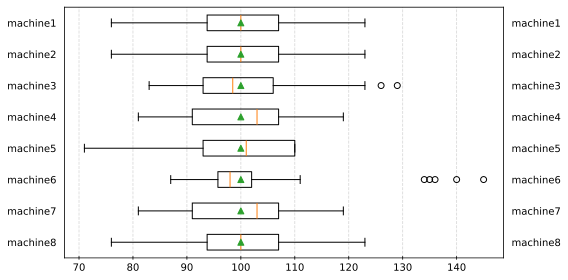

In [ ]:
# 箱ひげ図の描画
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

df = pd.read_csv('measurement.csv')

fig, ax = plt.subplots(figsize=(8,4),facecolor='white')
ax.boxplot(df, tick_labels=df.columns, vert=False, showmeans=True)
# 👆【演習】vert や showmeans がどのように効いてくるのか確認してください。

# Y軸設定
ax.invert_yaxis() # 反転
ax.tick_params(axis='y', length=0, labelright=True, pad=8)
# 👆【演習】labelright や pad がどのように効いてくるのか確認してください。

# X軸設定
ax.tick_params(axis='x', direction='inout')

ax.grid(axis='x', linestyle='--', alpha=0.5) # グリッド表示

plt.tight_layout()
plt.show()

### **定着確認**

- 上記の箱ひげ図の「オレンジ色の線」は何を示しているか答えよ。
- 上記の箱ひげ図の「緑色の三角形」は何を示しているか答えよ。
- 上記の箱ひげ図において、第1四分位点 $\mathrm{Q1}$ はどの部分（図のどの要素）に注目すれば読み取れるか答えよ。
- 上記の箱ひげ図において、第3四分位点 $\mathrm{Q3}$ はどの部分（図のどの要素）に注目すれば読み取れるか答えよ。
- 四分位範囲（IQR：Interquartile range）とは何か答えよ。
- 外れ値（図内の○印）は、どのような基準で描画されるか答えよ。

解答例は、情報3の [第09回講義資料](https://omunet-my.sharepoint.com/:b:/g/personal/z21707r_omu_ac_jp/EWN1qGRWItlJgxKzkzuVMFIBss8ZtAQVPXy-N31gw2CTBw?e=E2efcS) の p.188 ～ を参照してください。



## **箱ひげ図の整形と「最短50%区間」の表示**

箱ひげ図を作成することで各機械の特性を明確にすることができました。

このように **<font color="deeppink">平均や標準偏差からは確認できない情報があるため、データ分析では適切な可視化が必要</font>** となります。

箱ひげ図をさらに整形して「**最短**$50\%$**区間**」も表示していきます。最短$50\%$区間は、「Shortest $50\%$ Interval」や「Highest Density Interval（HDI）」とも呼ばれ、<font color="deeppink">全体データの $50\%$ の要素を含む最も狭い連続区間</font>を意味します（データの密度が高い区間ともいえます）。以下では、オレンジ色の線で「最短50%区間」を示しています。

<br>


**🗨️<font color="deeppink">プロンプト例</font>**

> 箱ひげ図に「最短50%区間」を表示してください、と依頼されたのですが、「最短50%区間」がいまいち分かっていません。具体例を用いて丁寧に解説してください。


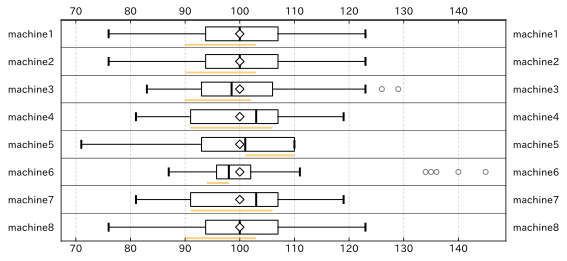

In [ ]:
#@title 箱ひげ図（最短50%区間付き） { display-mode: "form" }
# 箱ひげ図の描画
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

df = pd.read_csv('measurement.csv')

fig, ax = plt.subplots(figsize=(8,4),facecolor='white')

bp = ax.boxplot( df, tick_labels=df.columns,
    vert=False, showmeans=True, patch_artist=True,
    medianprops=dict(mec='black', linewidth=2, color='black'),
    meanprops=dict(mec='black', mfc='white', marker='D', linewidth=2),
    flierprops=dict(alpha=0.5, marker='o', markersize=5),
  )

for patch in bp['boxes'] :
  patch.set_facecolor('white')

for patch in bp['caps']:
  patch.set_linewidth(2)

# X軸設定 (上下表示)
ax.tick_params(axis='x', direction='in')
ax2 = ax.secondary_xaxis('top')
ax2.tick_params(axis='x', direction='in')

# Y軸設定
ax.invert_yaxis()
ax.set_yticks(np.arange(0.5, len(df.columns)), minor=True);
ax.tick_params(axis='y', which='major', labelright=True, left=False)
ax.tick_params(axis='y', which='minor', length=0)

# グリッド表示
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.grid(axis='y', which='minor', linewidth=0.5, color='black')

# ==== 最短50%区間の追加 ====
for i, col in enumerate(df.columns):
  data = df[col].dropna().sort_values().values
  n = len(data)
  width = int(np.floor(n * 0.5))

  min_width = np.inf
  best_interval = (None, None)

  for j in range(n - width):
    start = data[j]
    end = data[j + width]
    if (end - start) < min_width:
        min_width = end - start
        best_interval = (start, end)

  y = i + 1  # boxplotのy位置（1-based）
  ax.hlines(y=y+0.4, xmin=best_interval[0], xmax=best_interval[1],
            color='orange', linewidth=2, alpha=0.5, label='Shortest 50%' if i == 0 else "")

plt.show()

machine4 のケースでは、第1四分位数（Q1）〜第3四分位数（Q3）の範囲（＝IQR）の内部に「最短50%区間」が存在し、さらにその区間幅が IQR よりも短くなっています（直感的には少し奇異に感じるかもしれません）。

このようなことは、例えば以下のようなデータで起こりえます。

```
[1, 2, 3, 4, 5, 6, 7, 8, 8, 8, 8, 10, 20, 21, 22, 23]
```

このデータは、要素数 $16$ 個からなります。

このとき、

- 第1四分位（Q1）は「$4$」
  - 小さい順に並べたときの $25\%$ の位置（$n=16$の場合は $16\times0.25=4$ 番目）の値
- 第3四分位（Q3）は「$10$」
  - 小さい順に並べたときの $75\%$ の位置（$n=16$の場合は $16\times0.75=12$ 番目）の値


となるため、$\mathrm{IQR} = [\,4, 10\,]$ となります。

一方、データ数 $16$ 個の $50\%$ は $8$ 個なので、「最短50%区間」は、連続する $8$ 個のデータを含む区間のうち、幅が最も短いものとして求めます。このデータでは、

```
4, 5, 6, 7, 8, 8, 8, 8
```

という $8$ 個の連続データを取ると、その区間は $[\,4, 8\,]$ となり、区間幅は $
8 - 4 = 4$ となります。

これは IQR の幅 $10 - 4 = 6$ よりも短くなっています。

## **ヒストグラムを利用した特性差の可視化**

ヒストグラムを使った「可視化」についても行ないます。「箱ひげ図」と「ヒストグラム」では、読み取り可能な情報がどのように違うのかについて考えてみてください。

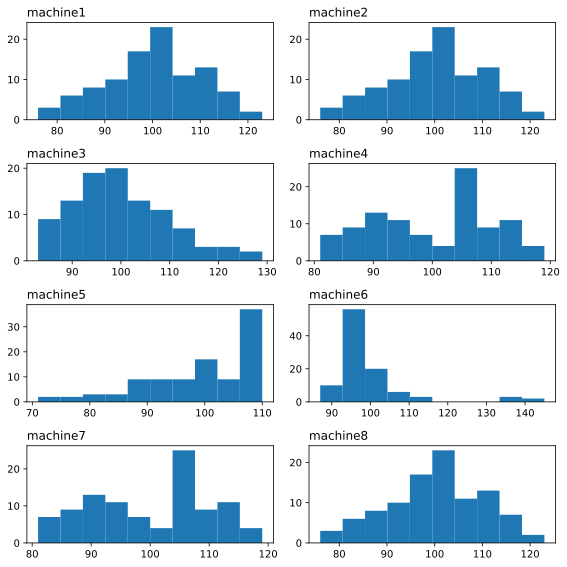

In [ ]:
#@title ヒストグラム { display-mode: "form" }
%reset -f

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

df = pd.read_csv('measurement.csv')

fig, axes = plt.subplots(nrows=4,ncols=2, figsize=(8,8), facecolor='white')
for i, ax in enumerate(axes.ravel(),1):
  c = f'machine{i}'
  ax.set_title(c,loc='left')
  ax.hist(df[c])

plt.tight_layout()
plt.show()

### **演習**

先に示した8個のヒストグラムは、機械の特性差を適切に比較できる形式とはなっていません（例えば、横軸と縦軸の範囲やスケールがグラフごとに異なっています）。これらのグラフを比較しやすいように適切に整形してください。

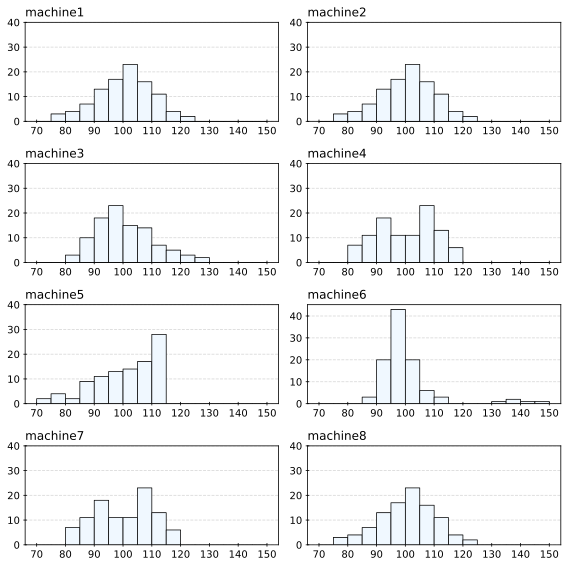

In [ ]:
#@title ⚠️演習の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

df = pd.read_csv('measurement.csv')

bins = np.arange(70,150+1,5)
xticks = np.arange(70,150+1,10)
yticks = np.arange(0,40+1,10)

fig, axes = plt.subplots(nrows=4,ncols=2, figsize=(8,8), facecolor='white')
for i, ax in enumerate(axes.ravel(),1):
  c = f'machine{i}'
  ax.set_title(c,loc='left')
  ax.hist(df[c],bins=bins, color='aliceblue', edgecolor ='black',linewidth=0.75)
  ax.set_xticks(xticks)
  ax.set_yticks(yticks)
  ax.tick_params(direction='inout')
  ax.grid(axis='y', linestyle='--', alpha=0.5)
  ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## **時系列データの可視化**

ここで取り扱っている `measurement.csv` は、$1$ 時間ごとに各機械で $1$ 個ずつサンプルを収集した時系列データが格納されています。このような時間的推移をともなうデータセットを「ヒストグラム」や「箱ひげ図」だけで分析すると、**<font color="deeppink">本質的な時系列特性を見落とすことがあります</font>**。

例えば「machine1」と「machine2」のヒストグラムは同じような分布形状となっていますが、**横軸に時間軸をとって可視化すると、両者の間に明確な特性的差異が表れます**。



### **演習**

`measurement.csv` の各機械のデータについて、横軸に時間軸、縦軸に豚饅重量をとって可視化せよ。

In [ ]:
%reset -f

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

df = pd.read_csv('measurement.csv')

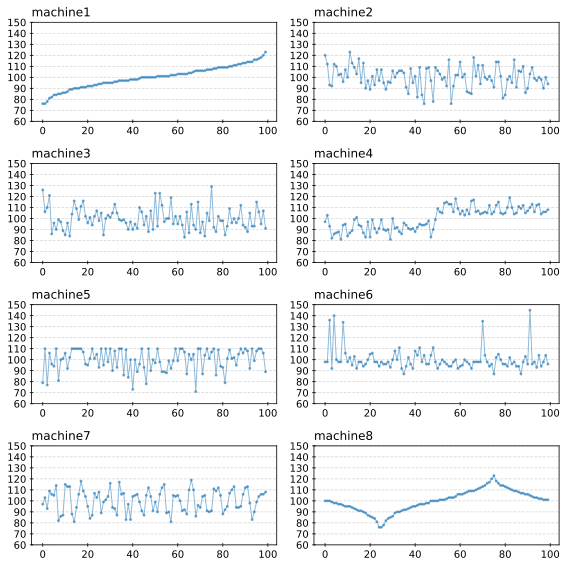

In [ ]:
#@title ⚠️演習の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

df = pd.read_csv('measurement.csv')

# xticks = np.arange(70,150+1,10)
yticks = np.arange(60,150+1,10)

fig, axes = plt.subplots(nrows=4,ncols=2, figsize=(8,8), facecolor='white')
for i, ax in enumerate(axes.ravel(),1):
  c = f'machine{i}'
  ax.set_title(c,loc='left')
  ax.plot(df[c],marker='.',alpha=0.5,ms=4,lw=1)
  # ax.set_xticks(xticks)
  ax.set_yticks(yticks)
  ax.tick_params(direction='inout')
  ax.grid(axis='y', linestyle='--', alpha=0.5)
  ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# **相関分析**

次のコードセルを実行して「実験用データ」を生成してください。



In [ ]:
# @title ■ 実験用のCSVデータの生成 { display-mode: "form" }
%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(16)
n = 100

#【1】
x  = np.random.normal(50,15,n).clip(0,100).astype(int)
y1 = np.random.normal(50,15,n).clip(0,100).astype(int)
df = pd.DataFrame({'x':x,'y':y1})

fn = 'data01-1.csv'
df.to_csv(fn,index=False)
print(f'{fn} を出力しました。')

#【2】
m = [50, 50] # 平均
s = [[310, 270],
     [270, 310]] #分散共分散行列
values = np.random.multivariate_normal(m, s, 100)
df = pd.DataFrame({'x':values[:,0].clip(0, 100).astype(int),
                   'y':values[:,1].clip(0, 100).astype(int)})
fn = 'data01-2.csv'
df.to_csv(fn,index=False)
print(f'{fn} を出力しました。')

#【3】
m = [50, 50] # 平均
s = [[340, -320],
     [-320, 340]] #分散共分散行列
values = np.random.multivariate_normal(m, s, 100)
df = pd.DataFrame({'x':values[:,0].clip(0, 100).astype(int),
                   'y':values[:,1].clip(0, 100).astype(int)})
fn = 'data01-3.csv'
df.to_csv(fn,index=False)
print(f'{fn} を出力しました。')

data01-1.csv を出力しました。
data01-2.csv を出力しました。
data01-3.csv を出力しました。


# **相関**

母集団から抽出した各個体について $2$ つの変量を取得し、それらを散布図にプロットしたとき、**2つの変量が何らかの関係性をもって一緒に変化しているような傾向** が見られる場合、これらの変量には何らかの関係があると予想されます。これを広義に「**相関がある**」と表現します。

このときの「変量の関係性」としては様々なパターンが考えられますが、以下に示す図の (2) や (3) のように、「一方が増えると、もう一方も増える（または減る）」といった**線形的な関係が見られるとき**、一般にそれぞれを「正の相関がある」「負の相関がある」のように表現します。



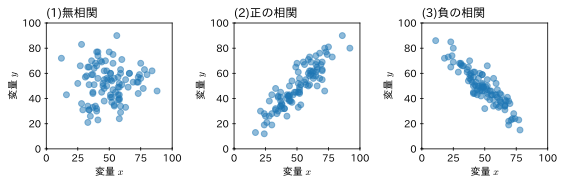

In [ ]:
# @title 相関 { display-mode: "form" }
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

dfs = []
for i in range(1,4):
  dfs.append(pd.read_csv(f'data01-{i}.csv'))

titles = ['無相関','正の相関','負の相関']

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(8,3),facecolor='white')
for i, ax in enumerate(axes.ravel()):
  ax.set_aspect('equal')
  ax.scatter(dfs[i]['x'],dfs[i]['y'],alpha=0.5)
  ax.set_xlim(0,100)
  ax.set_ylim(0,100);
  ax.set_xlabel('変量 $x$')
  ax.set_ylabel('変量 $y$')
  ax.set_title(f'({i+1}){titles[i]}',loc='left')
  ax.tick_params(direction='inout')

plt.tight_layout()
plt.show()

例えば、高専4年生という母集団の各個体（つまり、4Iの出席番号1番、2番、3番…という学生）から「身長」と「体重」という2変量を取得すると...

-  身長 $x$ が大きいと体重 $y$ も大きい傾向がある
-  身長 $x$ が小さいと体重 $y$ も小さい傾向がある

...のような関係性が見えてきます。このようなとき「身長と体重に相関がある」と表現します。

この他に、相関があるものの例としては...

1. 「コードの行数」と「バグの発生件数」
2. 「バージョンアップの頻度」と「依存ライブラリの不整合数」
3. 「コードレビューの厳しさ」と「コード品質」
4. 「開発メンバー数」と「コミュニケーションコスト」
5. 「コミットメッセージの具体性」と「バグ修正までに要する時間」
6. 「テスト自動化率」と「デプロイ頻度」

...などがあります。

### **演習**

上記の各例（1～6）について、予想されるのは「正の相関」か「負の相関」かを答えよ。

## **相関の定量化**

以上に示したような「線形的な関係の強さ」を定量的に評価する指標としては、**ピアソンの積率相関係数** $r$（単に「ピアソンの相関係数」や「相関係数」とも呼ばれる）が用いられます。相関係数 $r$ は次式で定義されます。

<br>

$$ r = \frac{c_{xy}}{s_{x}\cdot s_{y}} $$

<br>

ここで、$c_{xy}$、$s_{x}$、$s_{y}$ は次のように定義されます。

> 母集団 $\Omega$ から無作為にサンプルサイズ $n$ の標本 $\mathrm{S}$ を抽出したとします。そして、標本 $\mathrm{S}$ の各個体 $(i=1,2,\cdots,n)$ から $2$ つの変量 $x$ と $y$ を取得し、それぞれ $(x_1,y_1),\, (x_2,y_2),\, \cdots ,\, (x_n,y_n)$ と表します。
>
>変量 $x$ の平均を $\bar{x}$、変量 $y$ の平均を $\bar{y}$ とすれば、各変量の分散（$s^2_x$ と $s^2_y$）は以下のように定義されます（ここまでは復習です）。
>  
> <br>
> $$ s^2_x = \frac{1}{n}\sum_{i=1}^{n}(x_{i}-\bar{x})^2 $$
> <br>
> $$ s^2_y = \frac{1}{n}\sum_{i=1}^{n}(y_{i}-\bar{y})^2 $$
> <br>
>  
> また $c_{xy}$ は「**共分散**」と呼ばれ、以下のように定義されます。
>  
> <br>
> $$ c_{xy} = \frac{1}{n}\sum_{i=1}^{n} ( (x_{i} -\bar{x})(y_{i}-\bar{y})) $$


相関係数 $r$ は、常に $-1.0$ から $1.0$ の範囲の値を取り...

- $ r > 0 $：正の相関（ $x$ が増えると $y$ も増える傾向）
- $ r < 0 $：負の相関（ $x$ が増えると $y$ は減る傾向）
- $ r = 0 $：線形的な相関がない
  - ただし **非線形な関係（相関）** がある可能性はある。

...と解釈されます。

一般に、**相関係数の絶対値**  $|r|$ に基づいて、**相関の強さ** は以下のように評価されます。

- $ |r| \ge 0.7 $ ... **強い相関**がある
- $ 0.4 \le |r| < 0.7 $ ...  中程度の相関がある
- $ 0.2 \le |r| < 0.4 $ ... 弱い相関がある
- $ |r| < 0.2 $ ... **ほとんど相関**がない


## **例題**

次の問題を Python を利用して解け。

（教科書 p.24【 練習問題 [1] 】より抜粋）

> 次のデータは、あるプロ野球チームの主力投手 $16$ 人の身長と体重の組（$x \,[\mathrm{cm}]$、$y \,[\mathrm{kg}]$）を表したものである。このデータをもとに次の問いに答えよ。
>
> ```
> (179,90) (181,85) (186,94) (178,77) (182,91) (180,78)
> (188,88) (181,83) (179,82) (185,97) (186,87) (182,75)
> (173,80) (177,77) (176,85) (176,85) (181,86)
> ```
>
> (1) このデータの組の相関係数を求めよ。値は小数第 $3$ 位を四捨五入せよ。
>    - <font color='deeppink'>ここでは、この (1) の問題だけを考えます。</font>
>
> (2) 体重 $\mathrm{Y}$ の身長 $\mathrm{X}$ への回帰直線を求めよ。傾きは小数第 $4$ 位を、切片は小数第 $2$ 位をそれぞれ四捨五入して求めよ。


ピアソン相関係数 r = 0.57　※ 共分散から計算
ピアソン相関係数 r = 0.57　※ dfのcorrメソッドで計算
ピアソン相関係数 r = 0.57, p値 = 0.0213　※ scipy.stats で計算


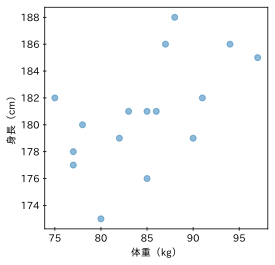

In [ ]:
%reset -f
import pandas as pd
import re
import scipy.stats as st

text = '''
(179,90) (181,85) (186,94) (178,77) (182,91) (180,78)
(188,88) (181,83) (179,82) (185,97) (186,87) (182,75)
(173,80) (177,77) (176,85) (181,86)
'''

# 正規表現で (数字,数字) の形式をすべて抽出
matches = re.findall(r'\((\d+),(\d+)\)', text)
# print(matches)

# DataFrame に変換
df = pd.DataFrame(matches, columns=['身長', '体重']).astype(int)
# display(df)

# 【1】相関係数を求める
cxy = df.cov(ddof=0).loc['身長', '体重'] # 共分散
sx = df['身長'].std(ddof=0) # 体重の分散
sy = df['体重'].std(ddof=0) # 身長の分散
r = cxy / (sx * sy)
print(f'ピアソン相関係数 r = {r:.2f}　※ 共分散から計算')

# 【2】相関係数を求める corr メソッド
r = df.corr(method='pearson').loc['身長', '体重']
print(f'ピアソン相関係数 r = {r:.2f}　※ dfのcorrメソッドで計算')

# 【3】相関係数を求める
r, p = st.pearsonr(df['身長'], df['体重'])
print(f'ピアソン相関係数 r = {r:.2f}, p値 = {p:.3g}　※ scipy.stats で計算')

import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

fig, ax = plt.subplots(figsize=(4,4),facecolor='white')
ax.scatter(x=df['体重'],y=df['身長'],alpha=0.5)

ax.tick_params(direction='inout')
ax.set_xlabel('体重（kg）')
ax.set_ylabel('身長（cm）')

plt.show()

scipy を使用すると、<font color='deeppink'>「無相関」を帰無仮説とした検定の $p$ 値を得ることができます</font>。これを利用すれば、以下のような分析が可能になります。

> 身長と体重の間に線形の関係が存在するかどうかを検討するため、ピアソンの積率相関係数に基づく検定を実施した。帰無仮説を「身長と体重の間に相関はない（$r = 0$）」とし、対立仮説を「身長と体重の間に相関がある（$r \neq 0$）」と設定した。
>
> その結果、相関係数は $r = 0.57$、対応する $p$ 値は $0.0213$ であった。これは、$5\%$ の有意水準において帰無仮説が棄却される水準であり、身長と体重の間に統計的に有意な正の相関が存在することが示された。
> 相関係数 $r = 0.57$ は一般的に「中程度の正の相関」と解釈される。すなわち、身長が高いほど体重も重くなる傾向があることが統計的に示唆される。
>

なお、相関関係はあくまで統計的な関連性を示すものであり、因果関係（たとえば「身長が原因で体重が増加する」など）を意味するものではない点に注意してください。

## **演習1**

次の問題を Python を利用して解いてください。

（教科書 p.20【例2.1】）

> あるクラスにおいて、科目Xと科目Yの成績データが次のように与えられている。このとき、科目Xと科目Yの間の相関係数 $r$ を求めよ。
>
> ```
> X = [35,80,45,85,95,67,52,59,73,70]
> Y = [50,90,38,68,88,80,70,54,69,45]
> ```
>
> また、「両者は無相関である」という帰無仮説のもとで検定を行い、対応する $p$ 値を算出せよ。その上で、有意水準 $5\%$ のもとで帰無仮説を棄却できるかどうかも判断せよ。

In [ ]:
%reset -f
import pandas as pd
import scipy.stats as st

X = [35,80,45,85,95,67,52,59,73,70]
Y = [50,90,38,68,88,80,70,54,69,45]

In [ ]:
#@title ⚠️演習1の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import pandas as pd
import scipy.stats as st

X = [35,80,45,85,95,67,52,59,73,70]
Y = [50,90,38,68,88,80,70,54,69,45]

cX = '科目X'
cY = '科目Y'

df = pd.DataFrame({cX:X, cY:Y}).astype(int)
r, p = st.pearsonr(df[cX], df[cY])
# print(f'ピアソン相関係数 r = {r:.2f}, p値 = {p:.3g}')

# 相関の強さ分類
abs_r = abs(r)
if abs_r >= 0.7:
    strength = "強い"
elif abs_r >= 0.4:
    strength = "中程度の"
elif abs_r >= 0.2:
    strength = "弱い"
else:
    strength = "ほとんど"

# 相関の正負
direction = "正の相関" if r > 0 else "負の相関" if r < 0 else "相関なし"

# 出力
print(f'相関係数は r = {r:.2f}、対応する p値は {p:.3f} であった。')

if p < 0.05:
  if strength == "ほとんど":
    print(f'これは、5% の有意水準において帰無仮説が棄却される水準であり、\n{cX}と{cY}の間には統計的に有意な相関があると判断されるが、その強さはごくわずかである。')
  else:
    print(f'これは、5% の有意水準において帰無仮説が棄却される水準であり、\n{cX}と{cY}の間には統計的に有意な「{strength}{direction}」が存在することが示された。')
else:
  print(f'これは、5% の有意水準において帰無仮説が棄却されない水準であり、\n{cX}と{cY}の間に統計的に有意な相関が存在するとは言えない。')


相関係数は r = 0.69、対応する p値は 0.027 であった。
これは、5% の有意水準において帰無仮説が棄却される水準であり、
科目Xと科目Yの間には統計的に有意な「中程度の正の相関」が存在することが示された。


## **「共分散」とは何か**

ここで、共分散 $c_{xy}$ や、相関係数 $r$ の「意味」について考えていきます。まず、**共分散** $c_{xy}$ は次のように定義されました。

<br>

$$ c_{xy} = \frac{1}{n}\sum_{i=1}^{n} ( (x_{i} -\bar{x})(y_{i}-\bar{y})) $$

<br>


これを展開すると次のようになります。

<br>

$$ c_{xy} = \frac{1}{n} ( (x_{1} -\bar{x})(y_{1}-\bar{y}) + (x_{2} -\bar{x})(y_{2}-\bar{y}) + \cdots + (x_{n} -\bar{x})(y_{n}-\bar{y})  ) $$

<br>

ここで、第 $i$ 項の値 $(x_{i} -\bar{x})(y_{i}-\bar{y}) $、つまり **偏差積** の正負は、下図のように、$\bar{x}$ と $\bar{y}$ によって区切られた区画のどこに位置するかで決まります。

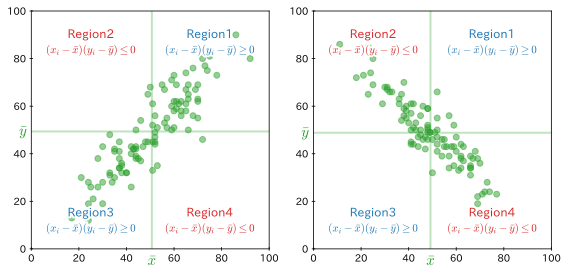

In [ ]:
# @title 共分散・偏差積の正負の関係 { display-mode: "form" }
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(ncols=2, figsize=(8,4),facecolor='white')

for i, ax in enumerate(axes.ravel()):

  df = pd.read_csv(f'data01-{2+i}.csv')
  ax.set_aspect('equal')
  ax.axvline(df['x'].mean(), c='tab:green',lw=2, alpha=0.3,zorder=0)
  ax.axhline(df['y'].mean(), c='tab:green',lw=2, alpha=0.3,zorder=0)

  ax.scatter(x=df['x'],y=df['y'],color='tab:green', alpha=0.5)
  ax.set_xlim(0,100)
  ax.set_ylim(0,100)

  ax.text(-2,df['y'].mean(),r'$\bar{y}$',ha='right',va='center',fontsize=15,c='tab:green')
  ax.text(df['x'].mean(),-2,r'$\bar{x}$',ha='center',va='top',fontsize=15,c='tab:green')

  for i, c in enumerate([(75,90,r'\geq'),(25,90,r'\leq'),(25,15,r'\geq'),(75,15,r'\leq')]):

    color = 'tab:blue' if c[2] == r'\geq' else 'tab:red'
    t = ax.text(c[0],c[1],f'Region{i+1}',fontsize=12,va='center',ha='center', color=color)
    t.set_path_effects([pe.withStroke(linewidth=4, foreground='white')])
    t = ax.text(c[0],c[1]-6.5,'$(x_{i}-\\bar{x})(y_{i}-\\bar{y})'+c[2]+'0$',
                color=color, fontsize=11,va='center',ha='center')
    t.set_path_effects([pe.withStroke(linewidth=4, foreground='white')])

  ax.tick_params(direction='inout')
  ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

ここで、Region 1 や 3 にプロットされる $(x, y)$ が多いときは、共分散が $c_{xy}> 0 $ となります。逆に、Region 2 や 4 にプロットされる $(x, y)$ が多いときは、共分散が $c_{xy}< 0 $ となります。

これより、共分散 $c_{xy}$ により、2つの変量についての「線形的な関係の強さ」を定量化できることが分かると思います。しかし、<font color='deeppink'>共分散 $c_{xy}$ は「変量の単位」や「サンプル数」によって値が変わるという扱いにくさがあります</font>。

例えば、体重を「$kg$ 単位」から「$g$ 単位」に変換すると、本質的に同じデータであっても 共分散 $c_{xy}$ の値が大きく変化します。

In [ ]:
%reset -f
import pandas as pd
import re

text = '''
(179,90) (181,85) (186,94) (178,77) (182,91) (180,78)
(188,88) (181,83) (179,82) (185,97) (186,87) (182,75)
(173,80) (177,77) (176,85) (181,86)
'''
matches = re.findall(r'\((\d+),(\d+)\)', text)
df = pd.DataFrame(matches, columns=['身長', '体重kg']).astype(int)
df['体重g'] = df['体重kg'] * 1000

cxy1 = df.cov(ddof=0).loc['身長', '体重kg'] # kg 単位のときの共分散
cxy2 = df.cov(ddof=0).loc['身長', '体重g']  #  g 単位のときの共分散

print(f'体重を kg 単位としたときの共分散 cxy1 = {cxy1:.1f}')
print(f'体重を  g 単位としたときの共分散 cxy2 = {cxy2:.1f}')

体重を kg 単位としたときの共分散 cxy1 = 13.6
体重を  g 単位としたときの共分散 cxy2 = 13648.4


このように「変量の単位」や「サンプルサイズ」に影響を受けるような統計量は、何らかの判断に用いる指標には適しません。そこで、範囲を $-1.0$ から $1.0$ の範囲にスケーリングするために、共分散 $c_{xy}$ を $s_{x}\cdot s_{y}$ で除してしたものが「**相関係数** $r$」となります。

$$ r = \frac{c_{xy}}{s_{x}\cdot s_{y}} $$

相関係数 $r$ は、変量の単位やサンプルサイズに関係なく、$-1.0 \le r \le 1.0$ となります。

In [ ]:
%reset -f
import pandas as pd
import re

text = '''
(179,90) (181,85) (186,94) (178,77) (182,91) (180,78)
(188,88) (181,83) (179,82) (185,97) (186,87) (182,75)
(173,80) (177,77) (176,85) (181,86)
'''
matches = re.findall(r'\((\d+),(\d+)\)', text)
df = pd.DataFrame(matches, columns=['身長', '体重kg']).astype(int)
df['体重g'] = df['体重kg'] * 1000

r1 = df.corr(method='pearson').loc['身長', '体重kg'] # kg 単位のときの相関係数
r2 = df.corr(method='pearson').loc['身長', '体重g']  #  g 単位のときの相関係数

print(f'体重を kg 単位としたときの相関係数 r1 = {r1:.3f}')
print(f'体重を  g 単位としたときの相関係数 r2 = {r2:.3f}')

体重を kg 単位としたときの相関係数 r1 = 0.569
体重を  g 単位としたときの相関係数 r2 = 0.569


## **相関係数は外れ値の影響を受けやすい**

相関係数 $r$ のベースとなる共分散 $c_{xy}$ を構成する $(x_{i}-\bar{x})(y_{i}-\bar{y})$ の大きさを可視化すると次のようになります。これより、図の四隅に「外れ値」あるとき、相関係数 $r$ に対して大きな影響を与えることが分かると思います。

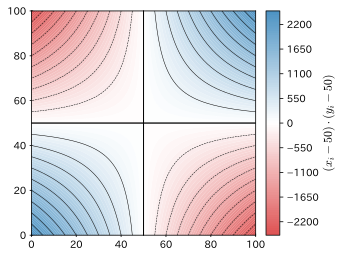

In [ ]:
#@title $(x_{i}-\bar{x})(y_{i}-\bar{y})$ の値を可視化 { display-mode: "form" }

%reset -f
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

# データの生成
x = np.linspace(0, 100, 200)
y = np.linspace(0, 100, 200)
X, Y = np.meshgrid(x, y)
Z = (X - 50) * (Y - 50)

# カスタムカラーマップの作成
colors = ['tab:red', 'white', 'tab:blue']
custom_cmap = LinearSegmentedColormap.from_list('custom_red_white_blue', colors, N=256)
norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())

# メイン描画領域
fig = plt.figure(figsize=(4.8, 4), facecolor='white')  # 横に余裕を持たせる
ax = fig.add_axes([0.1, 0.1, 0.65, 0.8])  # [left, bottom, width, height]
ax.set_aspect('equal')

# 等高線描画
contour = ax.contourf(X, Y, Z, levels=100, cmap=custom_cmap, norm=norm, alpha=0.8)
ax.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5)
ax.axvline(50, color='black', lw=1)
ax.axhline(50, color='black', lw=1)
ax.tick_params(direction='inout')
ax.set_axisbelow(True)

# 調整
ax = fig.add_axes([0.78, 0.11, 0.04, 0.78])  # 左位置, 下位置, 幅, 高さ
cbar = fig.colorbar(contour, cax=ax)
cbar.ax.set_ylabel('$(x_i-50)\cdot (y_i-50)$', fontsize=12)

plt.show()

## **定着確認**

- Region1 に位置するデータの **偏差積** $(x_{k} -\bar{x})(y_{k}-\bar{y}) $ の正負を答えよ。
- 同様に、Region2、Region3、Region4 に位置するデータの **偏差積** $(x_{k} -\bar{x})(y_{k}-\bar{y}) $ の正負を答えよ。
- $x$ と $y$ の観測データの平均がそれぞれ、$\bar{x}=50$、$\bar{y}=50$ と与えられるとき、下図の $p_1$ から $p_2$ について偏差積の大小関係を下記のような形式で答えよ。
 - $p_{a} > p_{b} \fallingdotseq p_{c} \fallingdotseq p_{d} > 0 > p_{e} > p_{f} \fallingdotseq p_{g}$


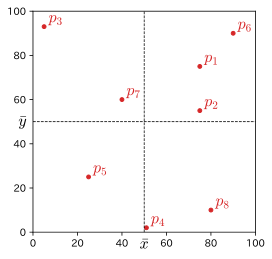

In [ ]:
# @title ■ 図の生成 { display-mode: "form" }
%reset -f
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

pp = [(75,75),(75,55),(5,93),(51,2),(25,25),(90,90),(40,60),(80,10)]

fig, ax = plt.subplots(figsize=(4,4),facecolor='white')
ax.axvline(50,c='black',ls='--',lw=0.75)
ax.axhline(50,c='black',ls='--',lw=0.75)
ax.set_xlim(0,100);
ax.set_ylim(0,100)
ax.text(-3,50,r'$\bar{y}$',ha='right',va='center',fontsize=16)
ax.text(50,-2,r'$\bar{x}$',ha='center',va='top',fontsize=16)

for i,p in enumerate(pp,1):
  ax.scatter(*p,c='tab:red',s=15)
  ax.text(p[0]+2,p[1]+2,f'$p_{i}$',fontsize=16,color='tab:red')

plt.show()

## **演習2**

外れ値の影響を評価せよ（外れ値を含むことで相関係数 $r$ は大きな影響を受けることを確認せよ）。

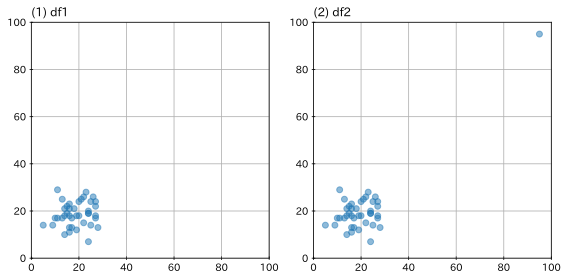

In [ ]:
# 外れ値の影響の評価【1】
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

# ダミーデータの準備
np.random.seed(30)
n = 40
x = np.random.normal(20,5,n).clip(0,None).astype(int)
y = np.random.normal(20,5,n).clip(0,None).astype(int)


# df1 を生成
df1 = pd.DataFrame({'x':x,'y':y})

# df2 を生成（df1に1件のデータを追加
df2 = pd.concat([df1, pd.DataFrame({'x':[95],'y':[95]})], ignore_index=True)

dfs = [df1, df2]

fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(8,4))
for i, ax in enumerate(axes.ravel()) :
  ax.scatter(dfs[i]['x'],dfs[i]['y'],alpha=0.5)
  ax.set_xlim(0,100);
  ax.set_ylim(0,100);
  ax.tick_params(direction='inout')
  ax.set_axisbelow(True)
  ax.set_title(f'({i+1}) df{i+1}',loc='left')
  ax.grid()

plt.tight_layout()
plt.show()

# df1とdf2について、それぞれ相関係数 r を計算して出力してください。

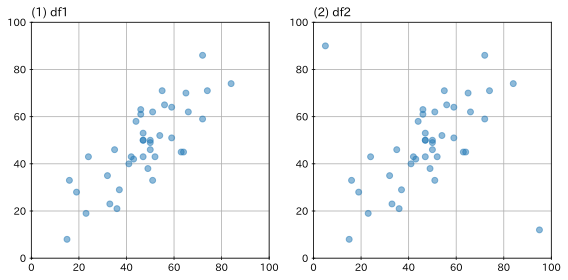

In [ ]:
# 外れ値の影響の評価【2】
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

# ダミーデータの準備
np.random.seed(37)
n = 40

# df1 を生成
m = [50, 50] # 平均
s = [[310, 270],[270, 310]] #分散共分散行列
values = np.random.multivariate_normal(m, s, n)
df1 = pd.DataFrame({'x':values[:,0].clip(0, 100).astype(int),
                    'y':values[:,1].clip(0, 100).astype(int)})

# df2 を生成（df1に2件のデータを追加
df2 = pd.concat([df1, pd.DataFrame({'x':[5,95],'y':[90,12]})], ignore_index=True)

dfs = [df1, df2]

fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(8,4))
for i, ax in enumerate(axes.ravel()) :
  ax.scatter(dfs[i]['x'],dfs[i]['y'],alpha=0.5)
  ax.set_xlim(0,100);
  ax.set_ylim(0,100);
  ax.tick_params(direction='inout')
  ax.set_axisbelow(True)
  ax.set_title(f'({i+1}) df{i+1}',loc='left')
  ax.grid()

plt.tight_layout()
plt.show()

# df1とdf2について、それぞれ相関係数 r を計算して出力してください。

以上のように、相関係数 $r$ は、外れ値の影響を非常に受けやすいという特徴があります。そのため、データをプロットせずに 相関係数 $r$ だけで評価すると、重要な特性を見逃す可能性があります。

その他、以下のように本来は「負の相関を持つデータ」にも関わらず、それらが混じることで、「正の相関」がでてしまうこともあります。

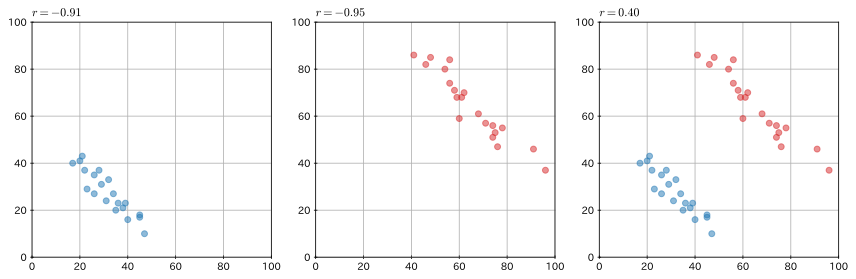

In [ ]:
#@title 適切な群分け（層分け）ができないと、相関が逆になることもあるので注意 { display-mode: "form" }

%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(35)
n = 20

# df1 を生成
m = [30, 30] # 平均
s = [[100,-90],
     [-90,100]] #分散共分散行列
values1 = np.random.multivariate_normal(m, s, n)
x1 = values1[:,0].clip(0, 100).astype(int)
y1 = values1[:,1].clip(0, 100).astype(int)

m = [65, 65] # 平均
values2 = np.random.multivariate_normal(m, s, n)
x2 = values2[:,0].clip(0, 100).astype(int)
y2 = values2[:,1].clip(0, 100).astype(int)

x3 = np.concatenate([x1,x2])
y3 = np.concatenate([y1,y2])

df1 = pd.DataFrame({'x':x1,'y':y1})
df2 = pd.DataFrame({'x':x2,'y':y2})
df3 = pd.DataFrame({'x':x3,'y':y3})

c1 = ['tab:blue']*n
c2 = ['tab:red']*n
c3 = ['tab:blue']*n + ['tab:red']*n

fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(12,4))
for ax, dft, c in zip(ax.ravel(),[df1,df2,df3],[c1,c2,c3]) :
  plt.sca(ax)
  plt.xlim(0,100);plt.ylim(0,100);
  plt.scatter(dft['x'],dft['y'],alpha=0.5,c=c)
  r = dft.corr(method='pearson').loc['x','y']
  plt.title(f'$r = {r:.2f}$',loc='left')
  plt.tick_params(direction='inout')
  plt.gca().set_axisbelow(True)
  plt.grid()

plt.tight_layout()
plt.show()

上の左図と中央図では、それぞれのグループの内部で「$x$ が大きいほど $y$ が小さくなる」という**負の相関**が見られます。相関係数も明確に $r=-0.91$、$r=-0.95$ と強い負の相関を示しています。

しかし、これら2つのグループを区別せずにまとめてしまった右図では、全体としては逆に「$x$ が大きいほど $y$ も大きい」という**正の相関** ($r=0.40$) が現れています。

これは、2つのグループ自体が

- 「低い値の集団」
- 「高い値の集団」

として大きく離れて存在しているためです。

つまり、

- 各グループの内部では「右下がり」
- しかしグループ全体の配置は「右上がり」

になっており、全体で集計すると後者の影響が強く現れてしまいます。

このように、適切な群分け（層分け）を行わずにデータをまとめると、本来の関係性とは逆の傾向が観測されることがあります。  
この現象は、統計学では **シンプソンのパラドックス（Simpson's paradox）** の代表例として知られています。

# **おまけ**

余裕があれば [ベイズ推定](https://colab.research.google.com/drive/1xijxfLc0tgC7Hzj8mwwQflO6iufA-oFX?usp=sharing) の資料もあるので読んでみてください (過去に専攻科1年の授業で使用していたものです)。